# **Initial biophysical characterization**

By: Daning Montaño
Date: 3/5/2026

This workbook provides basic information for characterizing ACUS ecosystems. It focuses on the use of GEE and remote sensing.

# **1. Libraries**

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import geemap
import ee
import math # Import the math module
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats

# **2. Initialize**

In [3]:
# Trigger the authentication flow.
#  Autenticar la cuenta de Google Earth Engine
ee.Authenticate()
ee.Initialize(project='monitoreofpachamama')

# **3. Data**

## 3.1. AOI

In [28]:
aoi =  ee.FeatureCollection("projects/monitoreofpachamama/assets/ZamoraCH/Provincia_ZCh")
aoi_buffer_5km = ee.FeatureCollection("projects/monitoreofpachamama/assets/ZamoraCH/Provincia_ZCh_5km_buffer")
acus = ee.FeatureCollection("projects/monitoreofpachamama/assets/ZamoraCH/ACUS_ZCH")

## 3.1. Remote sensing data

### DEM

30 meters

In [6]:
dem = ee.Image("USGS/SRTMGL1_003")
slope = ee.Terrain.slope(dem)

### Precipitation

5.6 km

In [5]:
chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")

### Surface temperature

1 km

In [11]:
# Cargar colección de imágenes MODIS - Temperatura superficial (LST)
# MOD11A2: 8-day composite of Land Surface Temperature
# Bandas: LST_Day_1km, LST_Night_1km, QC_Day, QC_Night

start_date = '2025-01-01'
end_date = '2025-12-31'

# Cargar MODIS LST
modis_lst = ee.ImageCollection('MODIS/061/MOD11A2') \
    .filterDate(start_date, end_date) \
    .select(['LST_Day_1km', 'LST_Night_1km', 'QC_Day', 'QC_Night'])


Temperature 2m

11.12 km

In [9]:
# Colección ERA5-LAND HOURLY
temperature_collection = (
    ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")
    .filterBounds(aoi)
    .select("temperature_2m")
)
print(f"ERA5-LAND MONTHLY_AGGR collection filtered for AOI: {temperature_collection.size().getInfo()} images found.")

ERA5-LAND MONTHLY_AGGR collection filtered for AOI: 914 images found.


### MODIS

500 m

In [10]:
# Load MODIS NDVI collections (v061)
modis_terra = ee.ImageCollection('MODIS/061/MOD13Q1').filterBounds(aoi)
modis_aqua = ee.ImageCollection('MODIS/061/MYD13Q1').filterBounds(aoi)

def mask_clouds_modis(img):
    # Obtener banda QA simplificada
    qa = img.select('SummaryQA')
    # En MODIS SummaryQA, 0 es 'Good Data' y 1 es 'Marginal Data'
    # Filtramos para quedarnos con datos confiables (bits 0 y 1)
    mask = qa.bitwiseAnd(3).lte(1)
    return img.updateMask(mask).select('EVI').divide(10000) \
              .copyProperties(img, ['system:time_start'])

# Aplicar máscara y combinar colecciones
filtered_terra = modis_terra.map(mask_clouds_modis)
filtered_aqua = modis_aqua.map(mask_clouds_modis)
merged_ndvi_collection = filtered_terra.merge(filtered_aqua).sort('system:time_start')

print(f"Colección NDVI procesada. Total de imágenes: {merged_ndvi_collection.size().getInfo()}")
print(f"Primer registro: {merged_ndvi_collection.first().date().format('YYYY-MM-DD').getInfo()}")

Colección NDVI procesada. Total de imágenes: 1150
Primer registro: 2000-02-49


# **4. Analysis**

## 4.1. Topographic

### DEM

In [49]:
dem_aoi = dem.clip(aoi)

## Map de DEM

# Define visualization parameters for the DEM
dem_vis_params = {
    'min': 0,
    'max': 4000,
    'palette': ['006633', 'E5FFCC', '662A00', '#FF8000', 'A6FFCC']
}

# Create a geemap.Map object
# Disable data controls to avoid fetching GOOGLE_MAPS_API_KEY outside Colab UI
map_dem = geemap.Map(data_ctrl=False)

# Add the clipped DEM layer to the map
map_dem.addLayer(dem_aoi, dem_vis_params, 'Digital Elevation Model')

# Create a styled layer for ACUS: outlines with a slight semi-transparent fill
# color: border color, fillColor: semi-transparent black (e.g., '00000033' for ~20% opacity)
acus_style = {'color': 'black', 'width': 1.5, 'fillColor': '00000033'}
map_dem.addLayer(acus.style(**acus_style), {}, 'Límites ACUS')

# Center the map on the AOI and display it
map_dem.centerObject(aoi, 9)
map_dem

Map(center=[-4.170786346022262, -78.90378780278299], controls=(WidgetControl(options=['position', 'transparent…

Plot Inside acus

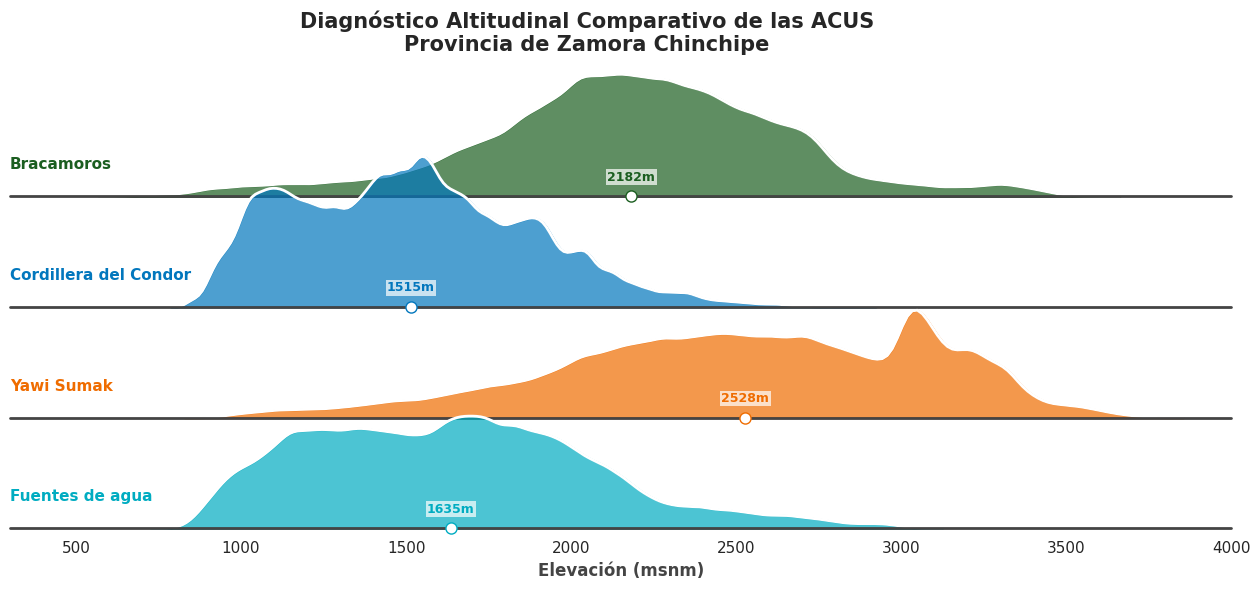

In [63]:

# 1. EXTRACCIÓN DE DATOS (Google Earth Engine)
nombres_categorias = acus.aggregate_array('Nombre').distinct().getInfo()
all_data = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))
    values_list = dem.reduceRegion(
        reducer=ee.Reducer.toList(),
        geometry=subset.geometry(),
        scale=90,
        maxPixels=1e8
    ).get('elevation').getInfo()

    if values_list:
        df_temp = pd.DataFrame({'Elevacion': values_list, 'ACUS': nombre})
        all_data.append(df_temp)

df_plot = pd.concat(all_data, ignore_index=True)

# 2. DISEÑO DE LA VISUALIZACIÓN (Ridgeline Plot)
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
custom_colors = ['#1B5E20', '#0277BD', '#EF6C00', '#00ACC1']

g = sns.FacetGrid(df_plot, row="ACUS", hue="ACUS", aspect=9, height=1.5, palette=custom_colors)

g.map(sns.kdeplot, "Elevacion", bw_adjust=.6, clip_on=False, fill=True, alpha=0.7, linewidth=1.5)
g.map(sns.kdeplot, "Elevacion", clip_on=False, color="white", lw=2, bw_adjust=.6)
g.map(plt.axhline, y=0, lw=2, clip_on=False, color="#444444")

# 3. FUNCIÓN DE ETIQUETADO CORREGIDA
def annotate_assets(x, color, label):
    ax = plt.gca()
    curr_mean = x.mean()

    # Nombre de la ACUS
    ax.text(0, 0.2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes, fontsize=11)

    # Punto de la media (en coordenadas de datos)
    ax.plot([curr_mean], [0], marker='o', color='white', markeredgecolor=color,
            markersize=8, zorder=10, clip_on=False)

    # Etiqueta de la media (ajustada para que coincida con el punto)
    ax.text(curr_mean, 0.0001, f'{curr_mean:.0f}m', color=color, fontweight='bold',
            ha="center", va="bottom", fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

g.map(annotate_assets, "Elevacion")

# 4. REFINAMIENTO
g.fig.subplots_adjust(hspace=-.3)
g.set_titles("")
g.set(yticks=[], ylabel="", xlim=(300, 4000))
g.despine(bottom=True, left=True)

plt.xlabel("Elevación (msnm)", fontsize=12, fontweight='bold', color='#444444')
plt.suptitle('Diagnóstico Altitudinal Comparativo de las ACUS\nProvincia de Zamora Chinchipe',
             fontsize=15, fontweight='bold', y=0.98)

plt.show()

In [65]:
# Calcular estadísticas principales del DEM para cada ACUS
stats_list = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))

    # Reductor combinado para eficiencia (corregido: se eliminó el argumento 'reducer=')
    reducers = ee.Reducer.mean() \
        .combine(ee.Reducer.stdDev(), '', True) \
        .combine(ee.Reducer.min(), '', True) \
        .combine(ee.Reducer.max(), '', True)

    stats = dem.reduceRegion(
        reducer=reducers,
        geometry=subset.geometry(),
        scale=90,
        maxPixels=1e8
    ).getInfo()

    if stats:
        stats_list.append({
            'ACUS': nombre,
            'Mínimo (msnm)': stats.get('elevation_min'),
            'Máximo (msnm)': stats.get('elevation_max'),
            'Media (msnm)': round(stats.get('elevation_mean'), 2),
            'Desv. Estándar': round(stats.get('elevation_stdDev'), 2)
        })

# Crear DataFrame y mostrar tabla
df_stats_dem = pd.DataFrame(stats_list)

# Estilizar la tabla para el reporte
print("Principales Estadísticas Altimétricas por ACUS")
display(df_stats_dem.style.background_gradient(subset=['Media (msnm)'], cmap='YlGnBu').format(precision=2))

Principales Estadísticas Altimétricas por ACUS


,ACUS,Mínimo (msnm),Máximo (msnm),Media (msnm),Desv. Estándar
0,Bracamoros,634,3587,2182.25,464.63
1,Cordillera del Condor,839,2866,1514.58,357.02
2,Yawi Sumak,904,3774,2528.12,548.52
3,Fuentes de agua,812,3061,1635.50,430.20


### Slope

In [51]:
slope_aoi = slope.clip(aoi)

# Define visualization parameters for the slope
slope_vis_params = {
    'min': 0,
    'max': 60,
    'palette': ['3ae237', 'b5c225', 'fd9122', 'ef8a33', 'ff0000']
}

# Create a geemap.Map object
# Disable data controls and explicitly set a non-Google basemap to prevent API key lookup issues
map_slope = geemap.Map(data_ctrl=False, basemap='OpenStreetMap')

# Add the clipped slope layer to the map
map_slope.addLayer(slope_aoi, slope_vis_params, 'Slope')

# Create a styled layer for ACUS: outlines with a slight semi-transparent fill
# color: border color, fillColor: semi-transparent black (e.g., '00000033' for ~20% opacity)
acus_style = {'color': 'black', 'width': 1.5, 'fillColor': '00000033'}
map_slope.addLayer(acus.style(**acus_style), {}, 'Límites ACUS')

# Center the map on the AOI and display it
map_slope.centerObject(aoi, 9)
map_slope

Map(center=[-4.170786346022262, -78.90378780278299], controls=(WidgetControl(options=['position', 'transparent…

Slope Inside ACUS

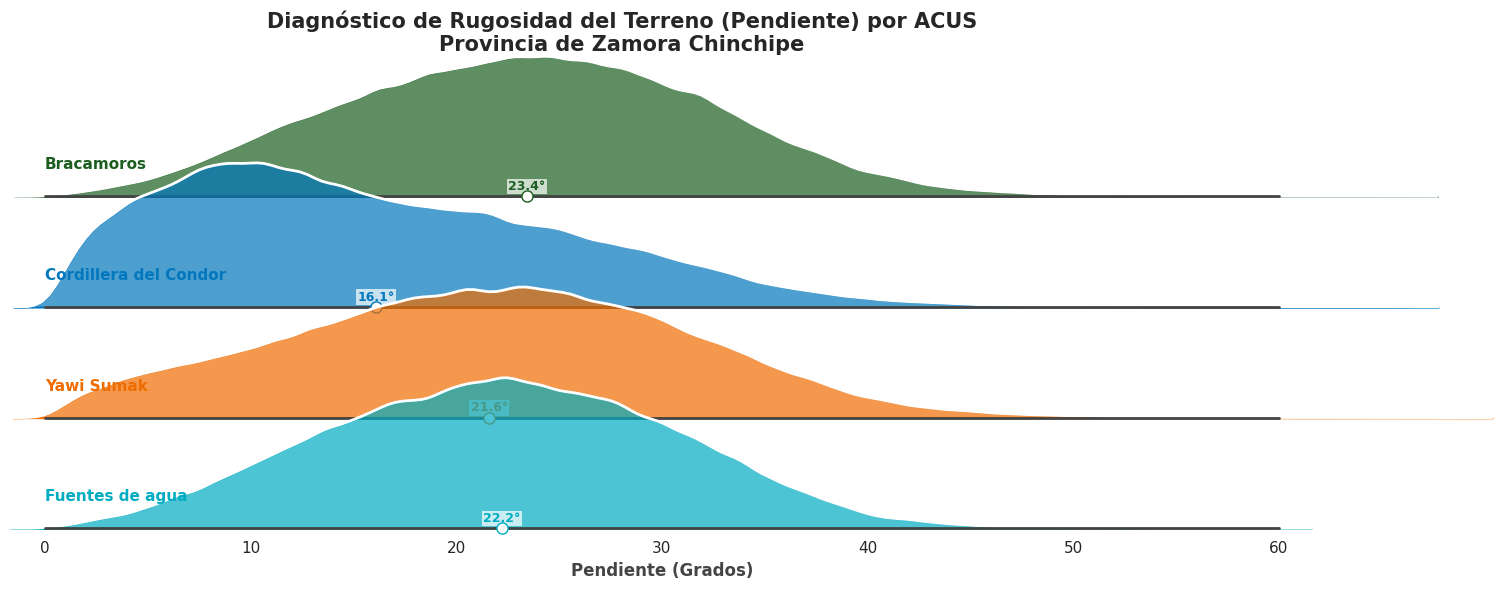

In [66]:
# 1. EXTRACCIÓN DE DATOS DE PENDIENTE (Google Earth Engine)
nombres_categorias = acus.aggregate_array('Nombre').distinct().getInfo()
all_slope_data = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))
    # Extraer valores de pendiente (slope)
    values_list = slope.reduceRegion(
        reducer=ee.Reducer.toList(),
        geometry=subset.geometry(),
        scale=90,
        maxPixels=1e8
    ).get('slope').getInfo()

    if values_list:
        df_temp = pd.DataFrame({'Pendiente': values_list, 'ACUS': nombre})
        all_slope_data.append(df_temp)

df_plot_slope = pd.concat(all_slope_data, ignore_index=True)

# 2. DISEÑO DE LA VISUALIZACIÓN (Ridgeline Plot)
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
custom_colors = ['#1B5E20', '#0277BD', '#EF6C00', '#00ACC1']

g = sns.FacetGrid(df_plot_slope, row="ACUS", hue="ACUS", aspect=9, height=1.5, palette=custom_colors)

# Mapeo de densidades
g.map(sns.kdeplot, "Pendiente", bw_adjust=.6, clip_on=False, fill=True, alpha=0.7, linewidth=1.5)
g.map(sns.kdeplot, "Pendiente", clip_on=False, color="white", lw=2, bw_adjust=.6)
g.map(plt.axhline, y=0, lw=2, clip_on=False, color="#444444")

# 3. FUNCIÓN DE ETIQUETADO (Adaptada para Pendiente)
def annotate_slope(x, color, label):
    ax = plt.gca()
    curr_mean = x.mean()

    # Nombre de la ACUS
    ax.text(0, 0.2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes, fontsize=11)

    # Punto de la media
    ax.plot([curr_mean], [0], marker='o', color='white', markeredgecolor=color,
            markersize=8, zorder=10, clip_on=False)

    # Etiqueta de la media
    ax.text(curr_mean, 0.001, f'{curr_mean:.1f}°', color=color, fontweight='bold',
            ha="center", va="bottom", fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

g.map(annotate_slope, "Pendiente")

# 4. REFINAMIENTO ESTÉTICO
g.fig.subplots_adjust(hspace=-.3)
g.set_titles("")
g.set(yticks=[], ylabel="", xlim=(0, 60)) # Rango típico de pendiente en grados
g.despine(bottom=True, left=True)

plt.xlabel("Pendiente (Grados)", fontsize=12, fontweight='bold', color='#444444')
plt.suptitle('Diagnóstico de Rugosidad del Terreno (Pendiente) por ACUS\nProvincia de Zamora Chinchipe',
             fontsize=15, fontweight='bold', y=0.98)

plt.show()

In [67]:
# Calcular estadísticas principales de la Pendiente para cada ACUS
stats_slope_list = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))

    # Reductor combinado para estadísticas de pendiente
    reducers = ee.Reducer.mean() \
        .combine(ee.Reducer.stdDev(), '', True) \
        .combine(ee.Reducer.min(), '', True) \
        .combine(ee.Reducer.max(), '', True)

    stats = slope.reduceRegion(
        reducer=reducers,
        geometry=subset.geometry(),
        scale=90,
        maxPixels=1e8
    ).getInfo()

    if stats:
        stats_slope_list.append({
            'ACUS': nombre,
            'Mínimo (°)': stats.get('slope_min'),
            'Máximo (°)': stats.get('slope_max'),
            'Media (°)': round(stats.get('slope_mean'), 2),
            'Desv. Estándar (°)': round(stats.get('slope_stdDev'), 2)
        })

# Crear DataFrame y mostrar tabla
df_stats_slope = pd.DataFrame(stats_slope_list)

# Estilizar la tabla para el reporte
print("Principales Estadísticas de Pendiente por ACUS")
display(df_stats_slope.style.background_gradient(subset=['Media (°)'], cmap='YlOrRd').format(precision=2))

Principales Estadísticas de Pendiente por ACUS


,ACUS,Mínimo (°),Máximo (°),Media (°),Desv. Estándar (°)
0,Bracamoros,0,66.26,23.43,8.84
1,Cordillera del Condor,0,66.22,16.10,9.55
2,Yawi Sumak,0,68.83,21.60,9.58
3,Fuentes de agua,0,59.86,22.20,8.42


### Slope classification

| Clase | Pendiente (grados) | Interpretación          |
| ----- | -----------------: | ----------------------- |
| 1     |               0–1° | Plano                   |
| 2     |               1–3° | Ligeramente inclinado   |
| 3     |               3–7° | Suavemente ondulado     |
| 4     |              7–14° | Moderadamente inclinado |
| 5     |             14–27° | Fuertemente inclinado   |
| 6     |             27–37° | Escarpado               |
| 7     |               >37° | Muy escarpado           |


In [22]:
# Function to classify slope based on criteria (slope in degrees)

def classify_slope(image):
    # The input 'image' is already in degrees, no conversion needed for classification by degrees.

    # Initialize classified_slope as an unmasked image with a default value (e.g., 0).
    # Then, apply classification rules using .where().
    classified_slope = ee.Image.constant(0).rename('Slope_Class_Degrees')

    # Classify the slope degree values using .where() for each condition
    classified_slope = classified_slope.where(image.lte(1), 1) # Class 1: 0-1°
    classified_slope = classified_slope.where(image.gt(1).And(image.lte(3)), 2) # Class 2: 1-3°
    classified_slope = classified_slope.where(image.gt(3).And(image.lte(7)), 3) # Class 3: 3-7°
    classified_slope = classified_slope.where(image.gt(7).And(image.lte(14)), 4) # Class 4: 7-14°
    classified_slope = classified_slope.where(image.gt(14).And(image.lte(27)), 5) # Class 5: 14-27°
    classified_slope = classified_slope.where(image.gt(27).And(image.lte(37)), 6) # Class 6: 27-37°
    classified_slope = classified_slope.where(image.gt(37), 7) # Class 7: >37°

    return classified_slope

# Apply the classification function to the clipped slope image
classified_slope_aoi = classify_slope(slope_aoi)
classified_slope_aoi = classified_slope_aoi.clip(aoi)
# Define visualization parameters for the classified slope
slope_class_vis = {
    'min': 1,
    'max': 7,
    'palette': [
        '#006837',  # Class 1: 0-1° (Plano)
        '#1a9850',  # Class 2: 1-3° (Ligeramente inclinado)
        '#66bd63',  # Class 3: 3-7° (Suavemente ondulado)
        '#d9ef8b',  # Class 4: 7-14° (Moderadamente inclinado)
        '#fee08b',  # Class 5: 14-27° (Fuertemente inclinado)
        '#fc8d59',  # Class 6: 27-37° (Escarpado)
        '#d73027'   # Class 7: >37° (Muy escarpado)
    ]
}

# Create a geemap.Map object
map_classified_slope = geemap.Map()

# Add the classified slope layer to the map
map_classified_slope.addLayer(classified_slope_aoi, slope_class_vis, 'Slope Classification (Degrees)')

# Center the map on the AOI and display it
map_classified_slope.centerObject(aoi, 9)
map_classified_slope

Map(center=[-4.170786346022262, -78.90378780278299], controls=(WidgetControl(options=['position', 'transparent…

Slope classes inside ACUS

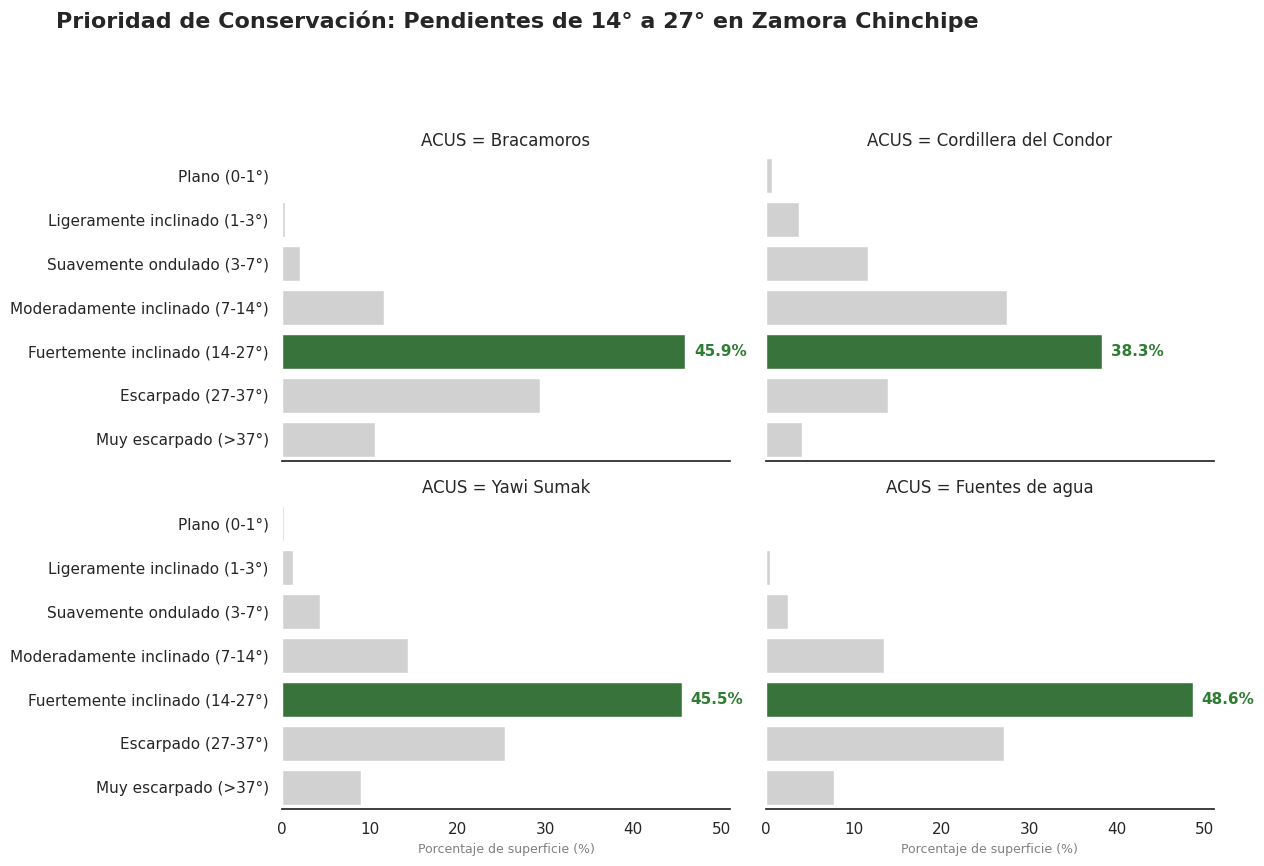

In [73]:


# --- FASE 1: ADQUIRIR Y ANALIZAR (Extracción de Datos GEE) ---
# Se procesan los datos espaciales para obtener la composición relativa del paisaje
data_list = []
for nombre in nombres_categorias:
    # 1. Definir geometría y reducir región (SRTM 30m)
    geom = acus.filter(ee.Filter.eq('Nombre', nombre)).geometry()
    hist = classified_slope_aoi.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=geom,
        scale=30,
        maxPixels=1e9
    ).get('Slope_Class_Degrees').getInfo()

    if hist:
        total_pixels = sum(hist.values())
        for class_id_str, count in hist.items():
            class_id = int(float(class_id_str))
            if class_id in slope_class_names:
                # Normalización a porcentaje para comparabilidad entre ACUS
                data_list.append({
                    'ACUS': nombre,
                    'Clase': slope_class_names[class_id],
                    'Porcentaje': (count / total_pixels) * 100
                })

df = pd.DataFrame(data_list)
df['Clase'] = pd.Categorical(df['Clase'], categories=ordered_slope_classes, ordered=True)

# --- FASE 2: REPRESENTAR Y REFINAR (Visualización Explicativa) ---
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'
main_class = 'Fuertemente inclinado (14-27°)' # Foco narrativo

# Facetas con escala compartida (0-100%) para comparación vertical directa
g = sns.FacetGrid(df, col='ACUS', col_wrap=2, height=4, aspect=1.6, sharex=True)

def draw_refined_bars(data, **kwargs):
    ax = plt.gca()
    # Atributo preatentivo: Solo la clase dominante tiene color
    colors = ['#2E7D32' if c == main_class else '#D1D1D1' for c in data['Clase']]

    sns.barplot(data=data, y='Clase', x='Porcentaje', palette=colors, ax=ax, hue='Clase', legend=False)

    # Etiquetado selectivo (Ratio datos-tinta): Solo la barra de interés
    for i, p in enumerate(ax.patches):
        width = p.get_width()
        class_name = data['Clase'].iloc[i]
        if class_name == main_class:
            ax.text(width + 1, i, f'{width:.1f}%',
                    va='center', fontsize=11, color='#2E7D32', fontweight='bold')

    # Eliminación de Clutter
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('Porcentaje de superficie (%)', fontsize=9, color='gray')

g.map_dataframe(draw_refined_bars)

# --- FASE 3: DELIVER (Storytelling con títulos interpretativos) ---
g.fig.suptitle('Prioridad de Conservación: Pendientes de 14° a 27° en Zamora Chinchipe',
               fontsize=16, fontweight='bold', x=0.05, ha='left', y=1.08)

plt.tight_layout()
plt.show()

### Length and slope angle (LS)

Cálculo del factor topográfico LS según Renard et al. (1997)

El factor LS representa el efecto combinado de la longitud de pendiente y la inclinación del terreno sobre el potencial de erosión hídrica en el modelo RUSLE.

La formulación general es:

$$
LS = L \times S
$$

donde \(L\) es el factor de longitud de pendiente y \(S\) es el factor de inclinación de pendiente.

Factor de longitud de pendiente

$$
L = \left(\frac{\lambda}{22.13}\right)^m
$$

donde:

$$
m = \frac{\beta}{1+\beta}
$$

$$
\beta =
\frac{
\left(\frac{\sin\theta}{0.0896}\right)
}{
3.0(\sin\theta)^{0.8}+0.56
}
$$

Factor de inclinación de pendiente

$$
S =
\begin{cases}
10.8\sin\theta + 0.03, & \text{si la pendiente} < 9\% \\
16.8\sin\theta - 0.50, & \text{si la pendiente} \geq 9\%
\end{cases}
$$

Fórmula completa

$$
LS =
\left(\frac{\lambda}{22.13}\right)^m
\times
\begin{cases}
10.8\sin\theta + 0.03, & \text{si la pendiente} < 9\% \\
16.8\sin\theta - 0.50, & \text{si la pendiente} \geq 9\%
\end{cases}
$$

con:

$$
m = \frac{\beta}{1+\beta}
$$

$$
\beta =
\frac{
\left(\frac{\sin\theta}{0.0896}\right)
}{
3.0(\sin\theta)^{0.8}+0.56
}
$$

Aplicación usada en este análisis

En este caso se usa la longitud estándar de parcela del modelo USLE/RUSLE:

$$
\lambda = 22.13 \ \text{m}
$$

Por tanto:

$$
L =
\left(\frac{22.13}{22.13}\right)^m = 1
$$

Entonces, el factor LS queda definido principalmente por el componente de inclinación de pendiente:

$$
LS = S
$$

Variables

| Símbolo | Significado |
|---|---|
| \(LS\) | Factor topográfico del modelo RUSLE |
| \(L\) | Factor de longitud de pendiente |
| \(S\) | Factor de inclinación de pendiente |
| \(\lambda\) | Longitud de pendiente en metros |
| \(22.13\) | Longitud estándar de la parcela USLE/RUSLE, en metros |
| \(\theta\) | Ángulo de pendiente en radianes |
| \(\sin\theta\) | Seno del ángulo de pendiente |
| \(m\) | Exponente de longitud de pendiente |
| \(\beta\) | Relación entre erosión en surcos e intersurcos |

In [101]:
# -------------------------------------------------------
# 1. Insumos requeridos
# -------------------------------------------------------
# Se asume que ya tienes:
# aoi       = área de estudio
# dem_aoi   = DEM recortado al área de estudio
# slope_aoi = pendiente en grados

# Pendiente en grados
slope_deg = slope_aoi.rename("slope_deg")

# Pendiente en radianes
slope_rad = slope_deg.multiply(math.pi).divide(180).rename("slope_rad")

# Seno de la pendiente
sin_theta = slope_rad.sin().rename("sin_theta")

# Pendiente en porcentaje
slope_pct = slope_rad.tan().multiply(100).rename("slope_pct")

# -------------------------------------------------------
# 2. Longitud de pendiente lambda
# -------------------------------------------------------
# Opción conservadora:
# usar la longitud estándar RUSLE = 22.13 m.
# Esto hace que L sea cercano a 1 y evita inflar el LS con acumulación de flujo.

lambda_img = ee.Image.constant(22.13).rename("lambda_m").clip(aoi)

# Si en el futuro tienes una capa real de longitud de pendiente,
# reemplaza la línea anterior por algo como:
# lambda_img = ee.Image("projects/tu_proyecto/assets/lambda_ladera").clip(aoi).rename("lambda_m")

# -------------------------------------------------------
# 3. Cálculo del exponente m
# -------------------------------------------------------
# beta = (sin(theta) / 0.0896) / [3.0 * sin(theta)^0.8 + 0.56]

beta = sin_theta.divide(0.0896).divide(
    sin_theta.pow(0.8).multiply(3.0).add(0.56)
).rename("beta")

# m = beta / (1 + beta)
m = beta.divide(beta.add(1)).rename("m")

# -------------------------------------------------------
# 4. Factor L
# -------------------------------------------------------
# L = (lambda / 22.13)^m

L = lambda_img.divide(22.13).pow(m).rename("L_Renard_1997")

# -------------------------------------------------------
# 5. Factor S
# -------------------------------------------------------
# Renard et al. 1997:
# si pendiente < 9%  -> S = 10.8 sin(theta) + 0.03
# si pendiente >= 9% -> S = 16.8 sin(theta) - 0.50

S_low = sin_theta.multiply(10.8).add(0.03)
S_high = sin_theta.multiply(16.8).subtract(0.50)

S = ee.Image(0) \
    .where(slope_pct.lt(9), S_low) \
    .where(slope_pct.gte(9), S_high) \
    .rename("S_Renard_1997")

# Evitar valores negativos de S en zonas casi planas
S = S.max(0.03).rename("S_Renard_1997")

# -------------------------------------------------------
# 6. Factor LS final
# -------------------------------------------------------

LS_Renard = L.multiply(S) \
    .rename("LS_Renard_1997") \
    .updateMask(dem_aoi.mask())



# -------------------------------------------------------
# 9. Visualización
# -------------------------------------------------------

map_ls_renard = geemap.Map(data_ctrl=False)
map_ls_renard.centerObject(aoi, 9)

ls_palette = ["#ffffcc", "#fecc5c", "#fd8d3c", "#e31a1c", "#800026"]

map_ls_renard.addLayer(
    slope_deg.clip(aoi),
    {
        "min": 0,
        "max": 45,
        "palette": ["#ffffcc", "#fd8d3c", "#800026"]
    },
    "Pendiente grados"
)

map_ls_renard.addLayer(
    L.clip(aoi),
    {
        "min": 0,
        "max": 5,
        "palette": ["#ffffcc", "#a1dab4", "#225ea8"]
    },
    "L Renard et al. 1997"
)

map_ls_renard.addLayer(
    S.clip(aoi),
    {
        "min": 0,
        "max": 10,
        "palette": ["#ffffcc", "#fd8d3c", "#bd0026"]
    },
    "S Renard et al. 1997"
)

map_ls_renard.addLayer(
    LS_Renard.clip(aoi),
    {
        "min": 0,
        "max": 14,
        "palette": ls_palette
    },
    "LS Renard et al. 1997"
)

map_ls_renard.addLayer(
    acus.style(**acus_style),
    {},
    "Límites ACUS"
)

map_ls_renard

Map(center=[-4.170786346022262, -78.90378780278299], controls=(WidgetControl(options=['position', 'transparent…

Inside Acus

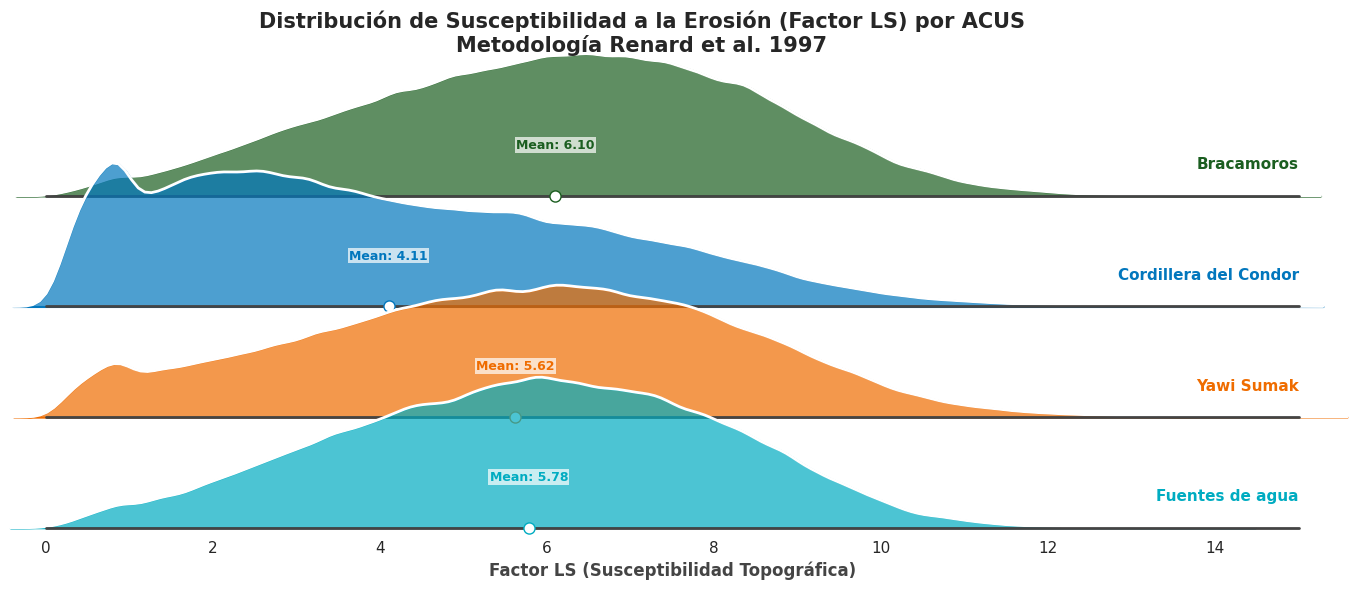

In [103]:

# 1. EXTRACCIÓN DE DATOS DEL FACTOR LS (Google Earth Engine)
# Usamos la variable LS_Renard definida anteriormente
nombres_categorias = acus.aggregate_array('Nombre').distinct().getInfo()
all_ls_data = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))
    # Extraer valores del Factor LS
    values_list = LS_Renard.reduceRegion(
        reducer=ee.Reducer.toList(),
        geometry=subset.geometry(),
        scale=90,
        maxPixels=1e8
    ).get('LS_Renard_1997').getInfo()

    if values_list:
        df_temp = pd.DataFrame({'LS_Factor': values_list, 'ACUS': nombre})
        all_ls_data.append(df_temp)

df_plot_ls = pd.concat(all_ls_data, ignore_index=True)

# 2. DISEÑO DE LA VISUALIZACIÓN (Ridgeline Plot)
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
custom_colors = ['#1B5E20', '#0277BD', '#EF6C00', '#00ACC1']

g = sns.FacetGrid(df_plot_ls, row="ACUS", hue="ACUS", aspect=9, height=1.5, palette=custom_colors)

# Mapeo de densidades (KDE)
g.map(sns.kdeplot, "LS_Factor", bw_adjust=.6, clip_on=False, fill=True, alpha=0.7, linewidth=1.5)
g.map(sns.kdeplot, "LS_Factor", clip_on=False, color="white", lw=2, bw_adjust=.6)
g.map(plt.axhline, y=0, lw=2, clip_on=False, color="#444444")

# 3. FUNCIÓN DE ETIQUETADO MODIFICADA (Nombres a la derecha)
def annotate_ls(x, color, label):
    ax = plt.gca()
    curr_mean = x.mean()

    # Nombre de la ACUS a la derecha (x=1 en transformAxes)
    ax.text(1, 0.2, label, fontweight="bold", color=color,
            ha="right", va="center", transform=ax.transAxes, fontsize=11)

    # Punto de la media
    ax.plot([curr_mean], [0], marker='o', color='white', markeredgecolor=color,
            markersize=8, zorder=10, clip_on=False)

    # Etiqueta de la media
    ax.text(curr_mean, 0.05, f'Mean: {curr_mean:.2f}', color=color, fontweight='bold',
            ha="center", va="bottom", fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

g.map(annotate_ls, "LS_Factor")

# 4. REFINAMIENTO
g.fig.subplots_adjust(hspace=-.3)
g.set_titles("")
g.set(yticks=[], ylabel="", xlim=(0, 15)) # Limitar a 15 ya que es el rango típico calculado
g.despine(bottom=True, left=True)

plt.xlabel("Factor LS (Susceptibilidad Topográfica)", fontsize=12, fontweight='bold', color='#444444')
plt.suptitle('Distribución de Susceptibilidad a la Erosión (Factor LS) por ACUS\nMetodología Renard et al. 1997',
             fontsize=15, fontweight='bold', y=0.98)

plt.show()

In [100]:

# Consolidar estadísticas de LS
ls_summary_data = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))

    # Reductor para el Factor LS
    # Usamos LS_Renard que es la variable definida en la celda anterior
    ls_stats = LS_Renard.reduceRegion(
            reducer=ee.Reducer.mean().combine(ee.Reducer.min(), '', True).combine(ee.Reducer.max(), '', True),
            geometry=subset.geometry(),
            scale=90,
            maxPixels=1e9
        ).getInfo()

    # Verificamos que las llaves existan y no sean None antes de redondear
    if ls_stats and ls_stats.get('LS_Renard_1997_mean') is not None:
        ls_summary_data.append({
            'ACUS': nombre,
            'LS Mínimo': round(ls_stats.get('LS_Renard_1997_min'), 2),
            'LS Máximo': round(ls_stats.get('LS_Renard_1997_max'), 2),
            'LS Medio': round(ls_stats.get('LS_Renard_1997_mean'), 2)
        })

# Crear el DataFrame de resumen de LS
df_ls_summary = pd.DataFrame(ls_summary_data)

# Mostrar tabla estilizada
if not df_ls_summary.empty:
    print("CUADRO RESUMEN: FACTOR LS POR ACUS")
    display(df_ls_summary.style.background_gradient(cmap='Reds', subset=['LS Medio'])\
           .set_caption("Estadísticas del Factor LS (Renard et al. 1997)"))
else:
    print("No se encontraron datos para las estadísticas de LS.")


CUADRO RESUMEN: FACTOR LS POR ACUS


,ACUS,LS Mínimo,LS Máximo,LS Medio
0,Bracamoros,0.030000,14.880000,6.100000
1,Cordillera del Condor,0.030000,14.870000,4.110000
2,Yawi Sumak,0.030000,15.170000,5.630000
3,Fuentes de agua,0.030000,14.030000,5.780000


## 4.2. Climate: Precipitation

### Precipitation - multi-year average

In [104]:
# 1. Definir el periodo de análisis
start_year = 1981
end_year = 2025

# 2. Función para calcular el acumulado anual
def get_annual_precip(year):
    date_start = ee.Date.fromYMD(year, 1, 1)
    date_end = ee.Date.fromYMD(year, 12, 31)

    annual_sum = chirps.filterDate(date_start, date_end) \
                       .sum() \
                       .set('year', year) \
                       .set('system:time_start', date_start.millis())
    return annual_sum

# 3. Crear una colección de imágenes anuales
years = ee.List.sequence(start_year, end_year)
annual_collection = ee.ImageCollection.fromImages(years.map(get_annual_precip))

# 4. Calcular el promedio multianual (Mean of annual sums)
mean_annual_precip = annual_collection.mean().clip(aoi)

# 5. Obtener el valor promedio para el AOI
stats = mean_annual_precip.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi.geometry(),
    scale=5566,
    maxPixels=1e9
).getInfo()

promedio_val = stats.get('precipitation')

print(f"Precipitación Promedio Multi-anual ({start_year}-{end_year}): {promedio_val:.2f} mm/año")

# 6. Visualización
map_precip = geemap.Map(data_ctrl=False)
map_precip.centerObject(aoi, 9)

precip_vis = {
    'min': 1000,
    'max': 4000,
    'palette': ['#f7fbff', '#deebf7', '#c6dbef', '#9ecae1', '#6baed6', '#4292c6', '#2171b5', '#084594']
}

map_precip.addLayer(mean_annual_precip, precip_vis, 'Precipitación Media Anual (mm)')
map_precip.addLayer(acus.style(**acus_style), {}, 'ACUS')
map_precip

Precipitación Promedio Multi-anual (1981-2025): 1607.38 mm/año


Map(center=[-4.170786346022255, -78.90378780278301], controls=(WidgetControl(options=['position', 'transparent…

Precipitation inside ACUS

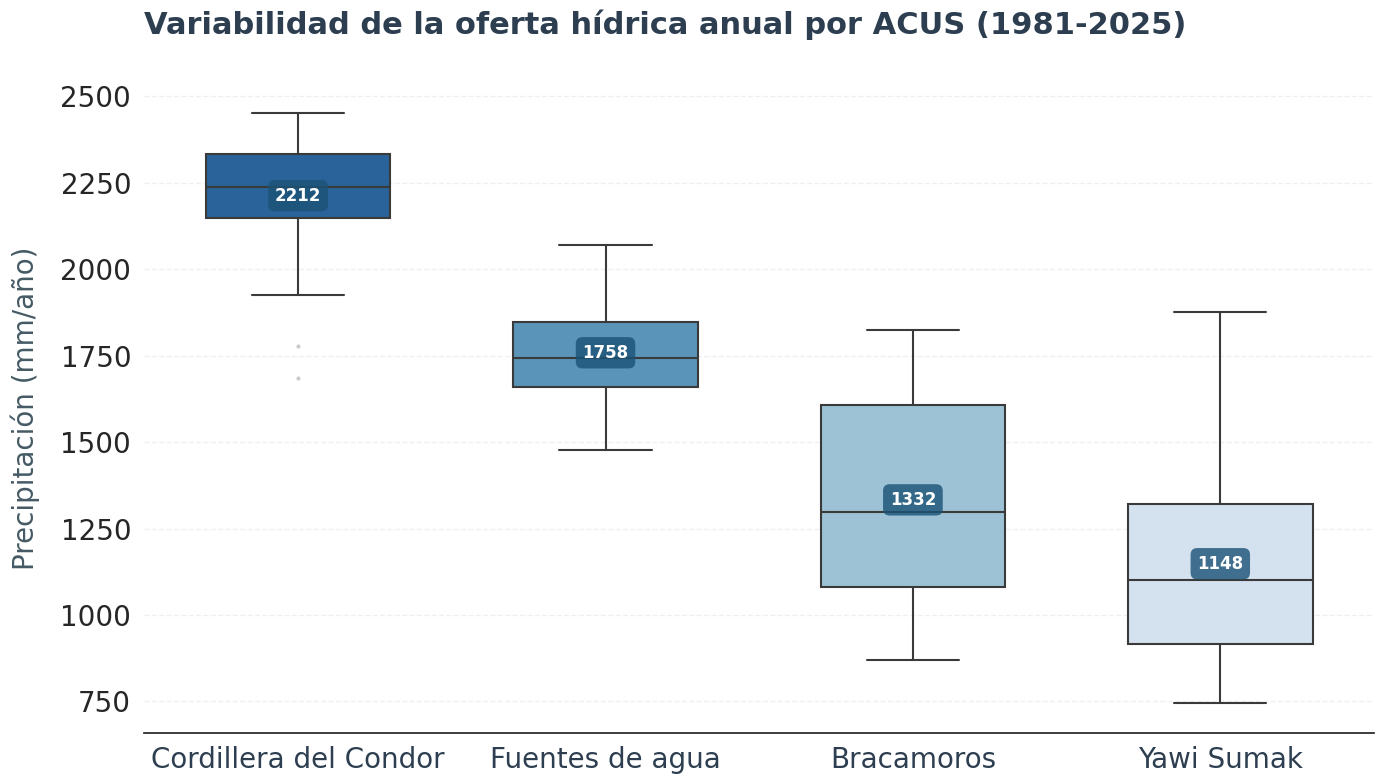

In [110]:
# --- 1. EXTRACCIÓN DE DATOS (GEE a Pandas) ---
nombres_categorias = acus.aggregate_array('Nombre').distinct().getInfo()
all_precip_data = []

for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))

    # Reducción de región para obtener la lista de valores de píxeles
    dict_values = mean_annual_precip.reduceRegion(
        reducer=ee.Reducer.toList(),
        geometry=subset.geometry(),
        scale=5566,
        maxPixels=1e8
    ).getInfo()

    values_list = dict_values.get('precipitation')

    if values_list:
        df_temp = pd.DataFrame({'Precipitacion': values_list, 'ACUS': nombre})
        all_precip_data.append(df_temp)

df_boxplot_precip = pd.concat(all_precip_data, ignore_index=True)

# --- 2. DISEÑO DE LA VISUALIZACIÓN (Análisis Explicativo) ---

# Orden lógico: De mayor a menor mediana para facilitar la comparación
order = df_boxplot_precip.groupby('ACUS')['Precipitacion'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 8))
sns.set_style("white") # Fondo limpio para maximizar ratio datos-tinta

# Paleta azulada secuencial (Simboliza agua/precipitación)
colors = sns.color_palette("Blues_r", len(order))

ax = sns.boxplot(
    data=df_boxplot_precip,
    x='ACUS',
    y='Precipitacion',
    order=order,
    palette=colors,
    width=0.6,
    linewidth=1.5,
    fliersize=3,
    flierprops={"markerfacecolor": "0.5", "markeredgecolor": "none", "alpha": 0.4}
)

# --- 3. REFINAMIENTO Y JERARQUÍA VISUAL ---

# Título interpretativo (La "Gran Idea")
plt.title('Variabilidad de la oferta hídrica anual por ACUS (1981-2025)',
          fontsize=22, loc='left', pad=35, color='#2c3e50', fontweight='bold')

# Etiquetas de ejes (Grandes y legibles)
plt.xlabel('', fontsize=20)
plt.ylabel('Precipitación (mm/año)', fontsize=20, color='#455a64', labelpad=15)

# Eliminación de bordes innecesarios
sns.despine(left=True, bottom=False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3) # Cuadrícula sutil solo horizontal

# Etiquetas del eje X horizontales (Evita carga cognitiva de rotación)
plt.xticks(fontsize=20, color='#2c3e50', rotation=0)
plt.yticks(fontsize=20)

# --- 4. ANOTACIÓN DE MEDIAS (Etiquetado Directo) ---
means = df_boxplot_precip.groupby('ACUS')['Precipitacion'].mean()
for i, name in enumerate(order):
    m = means[name]
    ax.text(
        i, m, f'{int(m)}',
        ha='center', va='center', fontsize=12,
        fontweight='bold', color='white',
        bbox=dict(facecolor='#1a5276', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.4')
    )

plt.tight_layout()
plt.show()

### Monthly precipitation

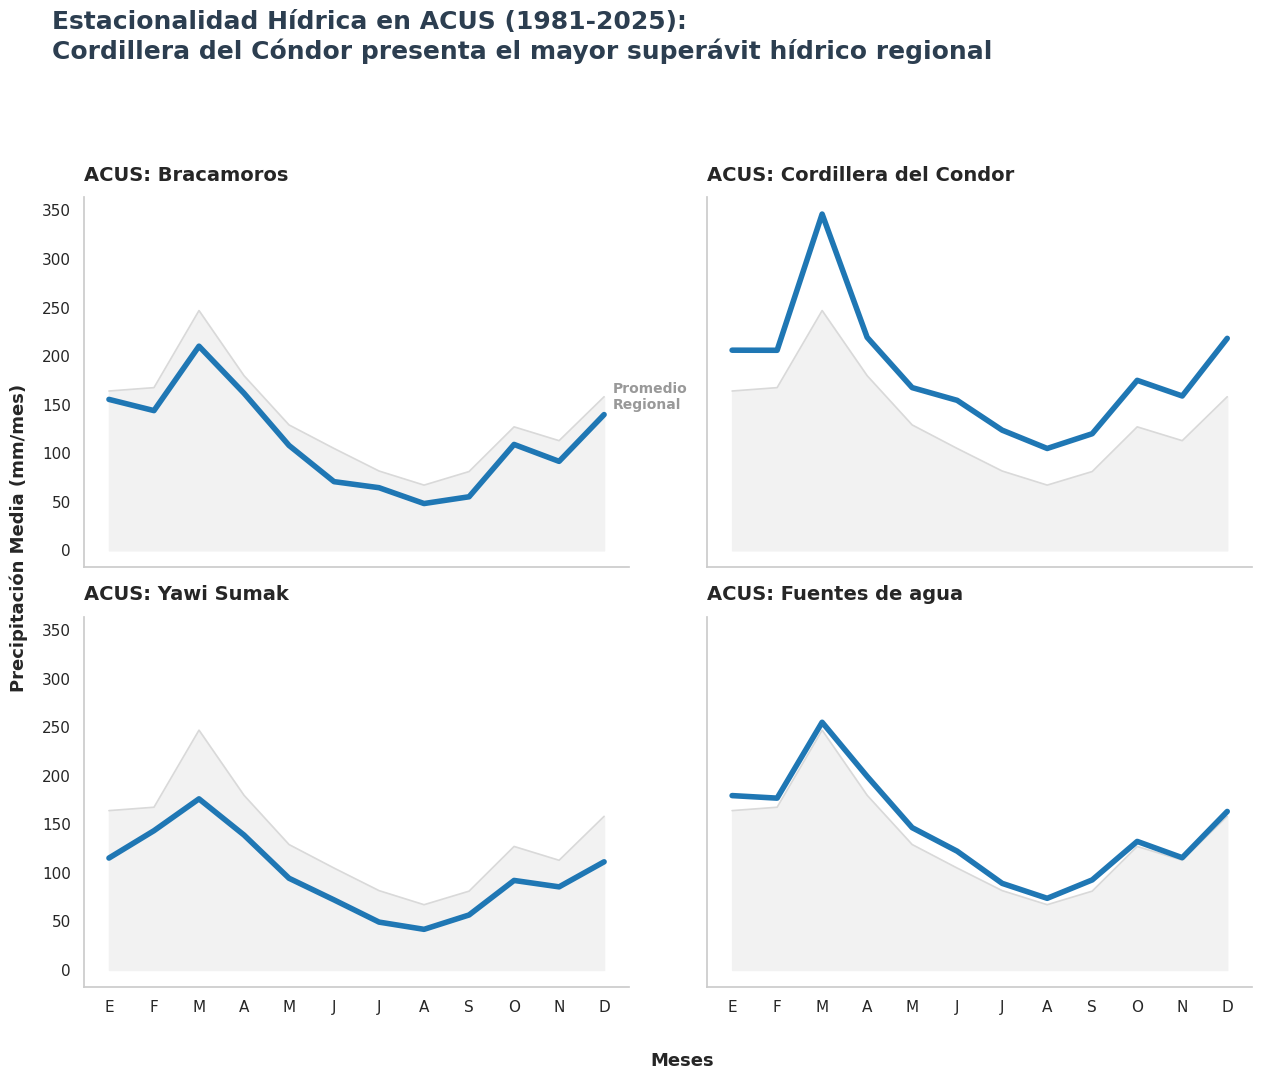

In [115]:
# Configuración de variables
start_year, end_year = 1981, 2025


chirps_filtered = chirps.filterDate(f'{start_year}-01-01', f'{end_year}-12-31')
months = ee.List.sequence(1, 12)

def get_monthly_mean(m):
    def get_annual_sum_for_month(y):
        return chirps_filtered.filter(ee.Filter.calendarRange(y, y, 'year')) \
                               .filter(ee.Filter.calendarRange(m, m, 'month')) \
                               .sum().set('month', m)
    annual_sums = ee.ImageCollection.fromImages(ee.List.sequence(start_year, end_year).map(get_annual_sum_for_month))
    return annual_sums.mean().set('month', m)

monthly_climatology = ee.ImageCollection.fromImages(months.map(get_monthly_mean))

# --- 2. FILTRAR Y MINAR (Extracción) ---
precip_monthly_data = []
# Se asume que 'nombres_categorias' y 'acus' están definidos en el entorno
for nombre in nombres_categorias[:4]: # Limitamos a 4 para el formato 2x2
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))
    def reduce_month(img):
        stats = img.reduceRegion(reducer=ee.Reducer.mean(), geometry=subset.geometry(), scale=5566, maxPixels=1e9)
        return ee.Feature(None, {'ACUS': nombre, 'Mes': img.get('month'), 'Precipitacion': stats.get('precipitation')})

    features = monthly_climatology.map(reduce_month).getInfo()['features']
    for f in features: precip_monthly_data.append(f['properties'])

df_monthly = pd.DataFrame(precip_monthly_data)
avg_regional = df_monthly.groupby('Mes')['Precipitacion'].mean()

# --- 3. REPRESENTAR Y REFINAR (Visualización para Informe) ---
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("white")

fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True, sharey=True)
axes = axes.flatten()
month_names = ['E', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

for i, nombre in enumerate(nombres_categorias[:4]):
    ax = axes[i]
    df_sub = df_monthly[df_monthly['ACUS'] == nombre]

    # 1. REFERENCIA: Promedio regional mejorado (Sombra)
    ax.fill_between(range(1, 13), avg_regional, color='#F2F2F2', alpha=1)
    ax.plot(range(1, 13), avg_regional, color='#D9D9D9', linewidth=1.2, linestyle='-')

    # 2. DATO PRINCIPAL: Línea de la ACUS resaltada
    ax.plot(range(1, 13), df_sub['Precipitacion'], color='#1f77b4', linewidth=4)

    # Etiquetas y Títulos con mayor tamaño (Legibilidad)
    ax.set_title(f"ACUS: {nombre}", fontsize=14, fontweight='bold', pad=12, loc='left')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names, fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    # Etiquetado directo del promedio (solo en el primer cuadrante)
    if i == 0:
        ax.text(12.2, avg_regional.iloc[-1], 'Promedio\nRegional',
                color='#999999', fontsize=10, fontweight='bold', va='center')

    # Eliminar ruido (Ratio datos-tinta)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')

# Título de Storytelling con Gran Idea
fig.suptitle('Estacionalidad Hídrica en ACUS (1981-2025):\nCordillera del Cóndor presenta el mayor superávit hídrico regional',
             fontsize=18, fontweight='bold', x=0.05, ha='left', color='#2C3E50')

# Etiquetas de ejes globales
fig.text(0.5, 0.02, 'Meses', ha='center', fontsize=13, fontweight='bold')
fig.text(0.02, 0.5, 'Precipitación Media (mm/mes)', va='center', rotation='vertical', fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0.03, 0.05, 0.92, 0.92])
plt.show()

### Time Series precipitation

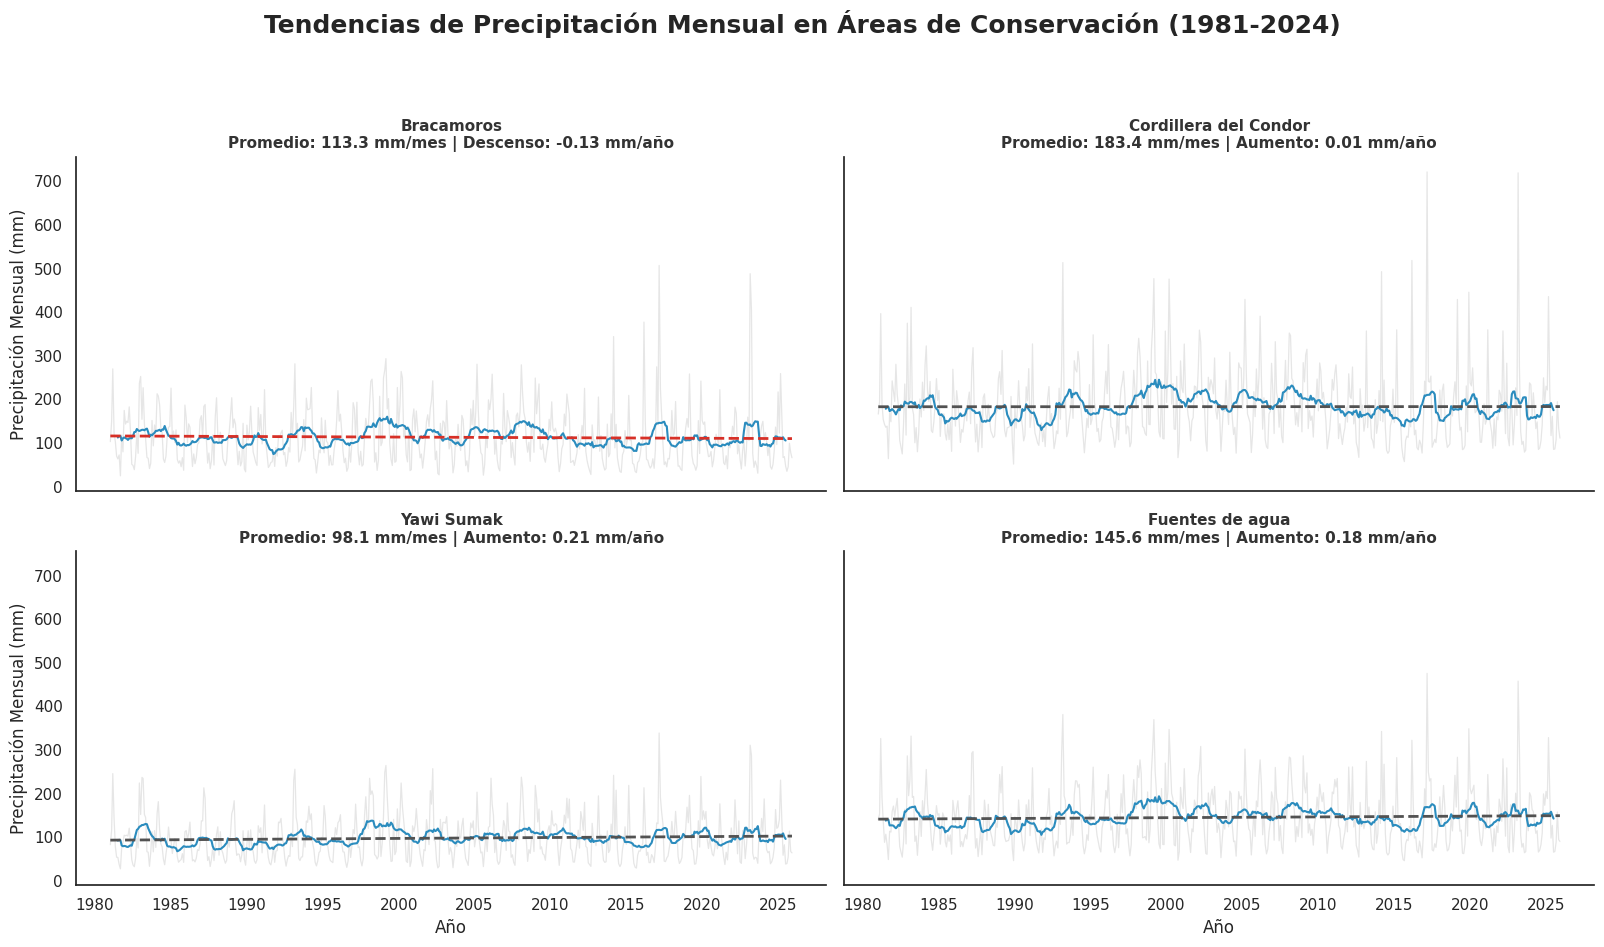

In [122]:
# --- 1. EXTRACCIÓN OPTIMIZADA (Google Earth Engine) ---
# Se recomienda usar esta lógica para evitar múltiples llamadas a getInfo()
start_year, end_year = 1981, 2025
years = ee.List.sequence(start_year, end_year)
months = ee.List.sequence(1, 12)

def get_monthly_images(y):
    return months.map(lambda m: chirps.filter(ee.Filter.calendarRange(y, y, 'year'))
                                     .filter(ee.Filter.calendarRange(m, m, 'month'))
                                     .sum()
                                     .set('year', y)
                                     .set('month', m)
                                     .set('system:time_start', ee.Date.fromYMD(y, m, 1).millis()))

monthly_chronology = ee.ImageCollection.fromImages(years.map(get_monthly_images).flatten())

all_features = []
for nombre in nombres_categorias:
    subset = acus.filter(ee.Filter.eq('Nombre', nombre))

    def reduce_region_ts(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=subset.geometry(),
            scale=5566,
            maxPixels=1e9
        )
        return ee.Feature(None, {
            'ACUS': nombre,
            'Time': img.get('system:time_start'),
            'Precipitacion': stats.get('precipitation')
        })

    # Procesamiento por sitio para mantener trazabilidad
    site_ts = monthly_chronology.map(reduce_region_ts).getInfo()['features']
    all_features.extend([f['properties'] for f in site_ts])

df_ts_full = pd.DataFrame(all_features)
df_ts_full['Fecha'] = pd.to_datetime(df_ts_full['Time'], unit='ms')

# --- 2. VISUALIZACIÓN REFINADA ---
sns.set_theme(style="white", rc={"axes.spines.right": False, "axes.spines.top": False})
g = sns.FacetGrid(df_ts_full, col="ACUS", col_wrap=2, height=4.5, aspect=1.8, sharey=True)

def plot_refined_trend(data, **kwargs):
    ax = plt.gca()
    data = data.sort_values('Fecha')

    # Datos mensuales (Ruido de fondo - 10% de énfasis)
    ax.plot(data['Fecha'], data['Precipitacion'], color='#E0E0E0', alpha=0.8, linewidth=0.9)

    # Media móvil de 12 meses (Ciclo anual)
    data['MA12'] = data['Precipitacion'].rolling(window=12, center=True).mean()
    ax.plot(data['Fecha'], data['MA12'], color='#2b8cbe', linewidth=1.5, label='Media Móvil 12m')

    # Tendencia Lineal
    x = np.arange(len(data))
    y = data['Precipitacion'].values
    # Manejo de NaNs para la regresión
    mask = ~np.isnan(y)
    slope, intercept, r_val, p_val, std_err = scipy.stats.linregress(x[mask], y[mask])

    # Resaltado preatentivo: Si la tendencia es negativa, usar un rojo más intenso
    trend_color = '#d73027' if slope < 0 else '#525252'
    ax.plot(data['Fecha'], intercept + slope * x, color=trend_color, linestyle='--', linewidth=2)

    # Título interpretativo por faceta
    trend_label = "Descenso" if slope < 0 else "Aumento"
    ax.set_title(f"{data['ACUS'].iloc[0]}\nPromedio: {data['Precipitacion'].mean():.1f} mm/mes | {trend_label}: {slope*12:.2f} mm/año",
                 fontweight='bold', fontsize=11, color='#333333')

g.map_dataframe(plot_refined_trend)
g.set_axis_labels("Año", "Precipitación Mensual (mm)")

# Título de la Gran Idea
g.fig.suptitle('Tendencias de Precipitación Mensual en Áreas de Conservación (1981-2024)',
               fontsize=18, fontweight='bold', y=1.05, color='#252525')

plt.tight_layout()
plt.show()